## Init

In [1]:
import os
import numpy as np
import itertools as it
import random
import pandas as pd
import multiprocess as mp
import time
import sys
import matplotlib.pyplot as plt

import torch

In [2]:
folder = "C:/Users/B00955739/Documents/Git/phd/Init/"

sys.path.append(folder)

import functions_v6_6 as fn
import ml_functions as mlf

In [3]:
folder = "C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/"
csv = "main_run_v2_corrected.csv"

In [4]:
out_name = "main_run_v2_corrected_grid_search_v2"

In [5]:
full_df = pd.read_csv(folder + csv)

In [6]:
keep_cols = ['system_id', 'dim', 'largest_lyap', 'embed_dim']

In [7]:
full_df_np = full_df[full_df.system_periodic == False]
full_df_np = full_df_np[keep_cols]

In [8]:
full_df_np['lyap_rank'] = full_df_np['largest_lyap'].rank(pct=True)
full_df_np['embed_rank'] = full_df_np['embed_dim'].rank(pct=True)

In [9]:
full_df_np.head()

,system_id,dim,largest_lyap,embed_dim,lyap_rank,embed_rank
0,0,1,0.000016,1.0,0.002867,0.008993
1,1,1,0.351925,1.0,0.171140,0.008993
2,2,1,4.000000,1.0,1.000000,0.008993
3,3,1,0.693147,1.0,0.286777,0.008993
4,4,1,0.417346,1.0,0.208785,0.008993


In [10]:
# full_df_np.to_csv(folder + "main_run_v2_nonperiodic_percentiles.csv")

In [11]:
## low lyap ~ 0.24 (10th percentile)
## medium lyap ~ 2.52 (50th percentile) 
## high lyap ~ 3.77 (90th percntile)

## low embed = 3/4 (~7/11th percentile)
## medium embed = 7 (39th percentile) 
## high embed ~ 9 (88th percntile)

systems = [
    56319, ## low embed low lyap
    2546,  ## low embed med lyap
    260860,  ## low embed high lyap
    88724, ## med embed low lyap
    21911,  ## med embed med lyap
    259485,  ## med embed high lyap
    215037, ## high embed low lyap
    134744, ## high embed med lyap
    160340, ## high embed high lyap
]

In [12]:
selected = full_df_np[full_df_np.system_id.isin(systems)] 
selected.head(10)

,system_id,dim,largest_lyap,embed_dim,lyap_rank,embed_rank
1494,2546,3,2.528692,4.0,0.502071,0.110525
20680,21911,5,2.516834,7.0,0.499954,0.385960
55088,56319,7,0.244948,3.0,0.100009,0.071425
87493,88724,8,0.244944,7.0,0.100000,0.385960
133513,134744,8,2.517124,9.0,0.500000,0.875918
159109,160340,9,3.776491,9.0,0.900006,0.875918
213806,215037,9,0.244946,9.0,0.100003,0.875918
258254,259485,10,3.776491,7.0,0.900000,0.385960
259629,260860,10,3.776510,3.0,0.901672,0.071425


In [13]:
sys_df = full_df[full_df.system_id.isin(systems)]

In [14]:
layer_vals = [3, 4]
layer_size_vals = [100, 200]
lr_vals = [0.001]
batch_vals = [32]
epoch_vals = [25, 50, 100, 200, 300, 400, 500]

reps = 3

In [15]:
grid_search = []

for lv in layer_vals:
    for lsv in layer_size_vals:
        for lrv in lr_vals:
            for bv in batch_vals:
                mod_dict = {
                    "n_layers": lv,
                    "layer_size": lsv,
                    "lr": lrv,
                    "lr_drop": True,
                    "batch_size": bv
                }
                grid_search.append(mod_dict)

print(len(grid_search))

4


In [16]:
total_models = len(sys_df) * len(grid_search) * reps
print("Total models: {}".format(total_models))

progress_update = 200
update_at = np.unique(np.round(np.linspace(0, total_models, progress_update)))

Total models: 108


In [17]:
models_complete = 0

result_list = []

for row_id, row in sys_df.iterrows():
    system_id = int(row['system_id'])
    sim_file = row['sim_file']
    modelling_len = int(row['modelling_len'])
    testing_len = int(row['testing_len'])
    n_tests = int(row['n_tests'])
    test_len = int(row['test_len'])
    embed_dim = int(row['embed_dim'])
    largest_lyap = row['largest_lyap']

    sim = np.load(sim_file)
    assert len(sim) == modelling_len + testing_len
    modelling_series = sim[:modelling_len]
    testing_series = sim[-testing_len:]
    
    modelling_range = np.max(modelling_series) - np.min(modelling_series)
    sim_range = np.max(sim) - np.min(sim)
    
    assert len(modelling_series) == modelling_len
    assert len(testing_series) == testing_len
    test_dts = np.array(np.split(testing_series, n_tests))
    assert np.all(test_dts.shape == (n_tests, test_len))

    for param_id, model_params in enumerate(grid_search):
        for rep_id in range(reps):
            
            result_dict = {
                "system_id": system_id,
                "embed_dim": embed_dim,
                "largest_lyap": largest_lyap,
                "model_id": param_id,
                "rep_id": rep_id,
                "modelling_range": modelling_range,
                "sim_range": sim_range
            }
            
            result_dict.update(model_params)
            ## set random seed
            random_seed = int(system_id + 1234*param_id + 5678*rep_id)
            torch.manual_seed(random_seed)
            ##initialise model
            model = mlf.lstm(lstm_hs=model_params['layer_size'], lstm_nl=model_params['n_layers'])
            ## create dataloaders
            loader_dict = mlf.create_loaders(model_series=modelling_series, embed_dim=embed_dim, train_split=0.8,
                                             test_series=testing_series, batch_size=model_params['batch_size'])
            ## train model
            if model_params['lr_drop']:
                lr_decay_factor = 0.1
            else:
                lr_decay_factor = 1
                
            trained_models, final_epoch, timings = mlf.train_model(model=model, train_loader=loader_dict["train_loader"],
                                            val_loader=loader_dict["val_loader"], epochs=epoch_vals, patience=100,
                                            loss_fn=torch.nn.L1Loss(), opt=torch.optim.Adam, start_lr=model_params['lr'],
                                            lr_decay_factor=lr_decay_factor, if_save=False, save_folder=None, save_name=None,
                                            plot=False, verbose=False)

            result_dict["final_epoch"] = final_epoch

            for epoch_idx in range(len(trained_models)):
                final_dict = result_dict.copy()
                trained_model = trained_models[epoch_idx]
                final_dict["epoch"] = epoch_vals[epoch_idx]
                final_dict["model_time"] = timings[epoch_idx]
            
                final_dict["train_loss_mae"] = mlf.calc_loss(model=trained_model, dataloader=loader_dict["train_loader"], loss_fn=torch.nn.L1Loss())
                final_dict["val_loss_mae"] = mlf.calc_loss(model=trained_model, dataloader=loader_dict["val_loader"], loss_fn=torch.nn.L1Loss())
                final_dict.update(mlf.calc_point_metrics(model=trained_model, dataloader=loader_dict["test_loader"], prefix="test_loss"))
                
                pred_test_dts = mlf.pred_test_dts(test_dts=test_dts, model=trained_model, embed_dim=embed_dim)
    
                for t in [0.001, 0.01, 0.05]:
                    pred_h = fn.calc_pred_h(test_dts=test_dts, pred_dts=pred_test_dts, embed_dim=embed_dim, thresh=t,
                                            percentiles=[1, 5, 10, 25, 50, 75, 90, 95, 99], if_plot=False)
                    final_dict.update(pred_h)
                
                result_list.append(final_dict)
                
            models_complete += 1
            if models_complete in update_at:
                print("Completed training model {} of {} ({}%)".format(models_complete, total_models, np.round(100*(models_complete/total_models), 2)))

Completed training model 1 of 108 (0.93%)
Completed training model 2 of 108 (1.85%)
Completed training model 3 of 108 (2.78%)
Completed training model 4 of 108 (3.7%)
Completed training model 5 of 108 (4.63%)
Completed training model 6 of 108 (5.56%)
Completed training model 7 of 108 (6.48%)
Completed training model 8 of 108 (7.41%)
Completed training model 9 of 108 (8.33%)
Completed training model 10 of 108 (9.26%)
Completed training model 11 of 108 (10.19%)
Completed training model 12 of 108 (11.11%)
Completed training model 13 of 108 (12.04%)
Completed training model 14 of 108 (12.96%)
Completed training model 15 of 108 (13.89%)
Completed training model 16 of 108 (14.81%)
Completed training model 17 of 108 (15.74%)
Completed training model 18 of 108 (16.67%)
Completed training model 19 of 108 (17.59%)
Completed training model 20 of 108 (18.52%)
Completed training model 21 of 108 (19.44%)
Completed training model 22 of 108 (20.37%)
Completed training model 23 of 108 (21.3%)
Completed

In [18]:
res_df = pd.DataFrame(result_list)
res_df.head()

,system_id,embed_dim,largest_lyap,model_id,rep_id,modelling_range,sim_range,n_layers,layer_size,lr,...,pred_h_p5 t=0.05,pred_h_p10 t=0.05,pred_h_p25 t=0.05,pred_h_p50 t=0.05,pred_h_p75 t=0.05,pred_h_p90 t=0.05,pred_h_p95 t=0.05,pred_h_p99 t=0.05,pred_h_sd t=0.05,pred_h_perfect_pred_count t=0.05
0,2546,4,2.528692,0,0,0.862464,0.893973,3,100,0.001,...,0.0,0.0,0.0,0.0,0.0,1.0,1.05,2.0,0.509902,0
1,2546,4,2.528692,0,0,0.862464,0.893973,3,100,0.001,...,0.0,0.0,0.0,0.0,0.0,1.0,1.05,2.0,0.509902,0
2,2546,4,2.528692,0,0,0.862464,0.893973,3,100,0.001,...,0.0,0.0,0.0,0.0,0.0,1.0,1.05,2.0,0.509902,0
3,2546,4,2.528692,0,0,0.862464,0.893973,3,100,0.001,...,0.0,0.0,0.0,0.0,0.0,1.0,1.05,2.0,0.509902,0
4,2546,4,2.528692,0,0,0.862464,0.893973,3,100,0.001,...,0.0,0.0,0.0,0.0,0.0,1.0,1.05,2.0,0.509902,0


In [19]:
print("Saving CSV: {}".format(folder + out_name + ".csv"))

res_df.to_csv(folder + out_name + ".csv")

Saving CSV: C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/main_run_v2_corrected_grid_search_v2.csv


In [20]:
print(len(res_df))

756


## Analysis

In [130]:
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())
import copy

pd.options.mode.copy_on_write = True

In [26]:
q = 'select distinct system_id, model_id, rep_id, final_epoch from res_df'

early_finish_df = pysqldf(q)
early_finish_df.head()

,system_id,model_id,rep_id,final_epoch
0,2546,0,0,107
1,2546,0,1,118
2,2546,0,2,136
3,2546,1,0,134
4,2546,1,1,121


In [28]:
early_fin_counts = len(early_finish_df.final_epoch[early_finish_df.final_epoch < 500])
print(100* (early_fin_counts/len(early_finish_df.final_epoch)))

75.30864197530865


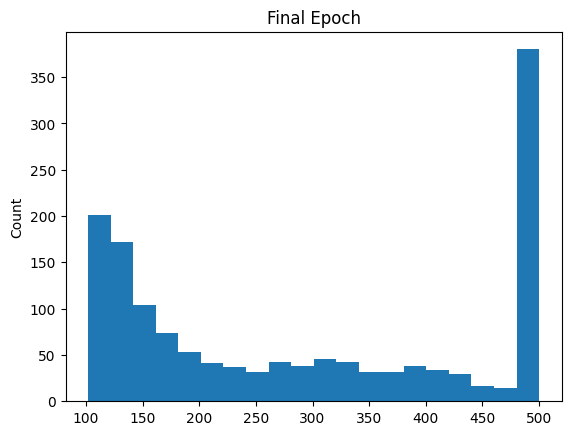

In [32]:
plt.figure()
plt.hist(early_finish_df.final_epoch, bins=20)
plt.title('Final Epoch')
plt.ylabel('Count')
plt.show()
plt.close()

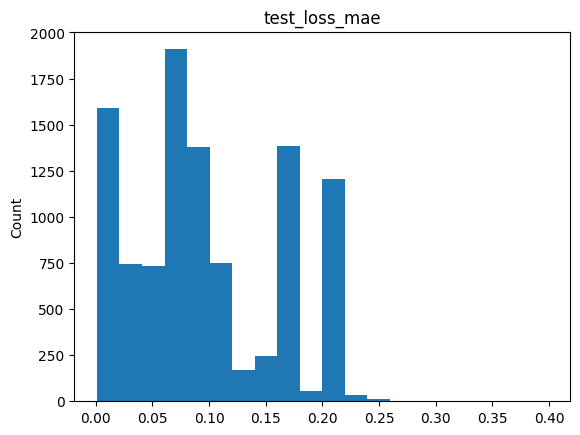

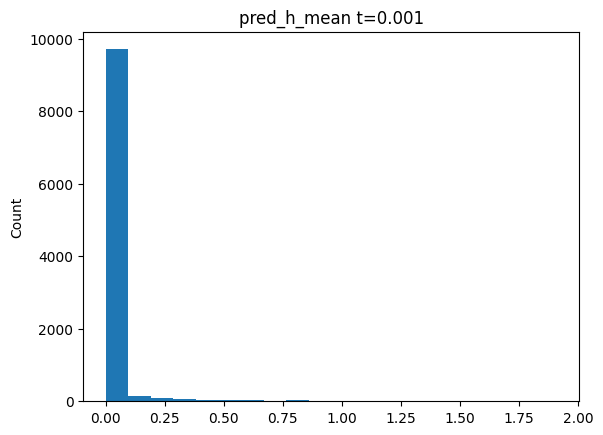

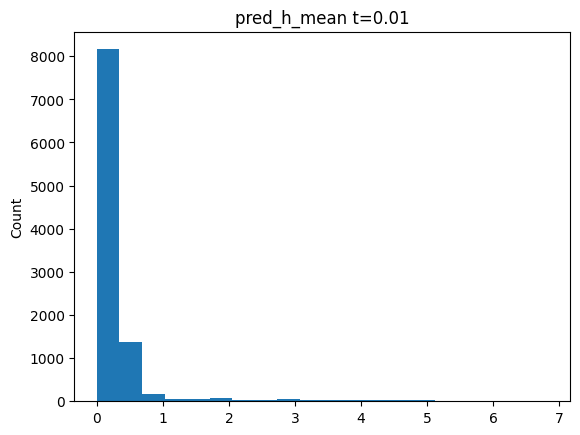

pred_h_mean t=0.05 2


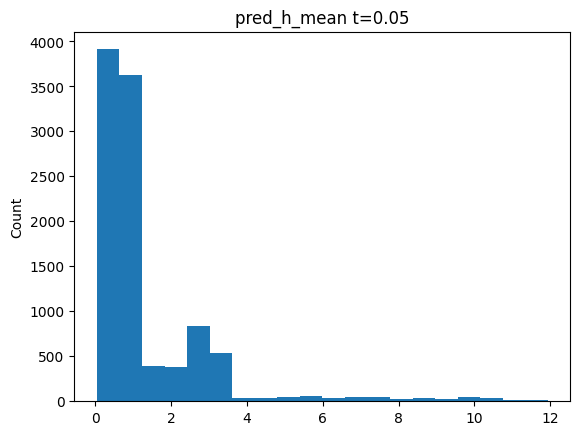

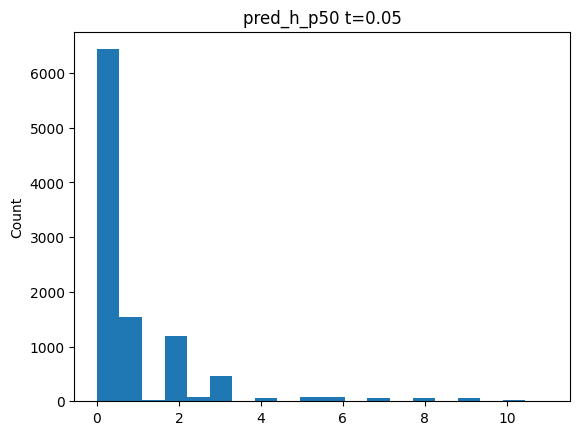

In [34]:
metrics = ['test_loss_mae', 'pred_h_mean t=0.001', 'pred_h_mean t=0.01', 'pred_h_mean t=0.05', 'pred_h_p50 t=0.05']

for m in metrics:
    arr = res_df[m]
    if np.any(res_df[m] == np.inf):
        print(m, sum(res_df[m] == np.inf))
        arr = res_df[m][res_df[m] != np.inf]
    plt.figure()
    plt.hist(arr, bins=20)
    plt.title(m)
    plt.ylabel('Count')
    plt.show()
    plt.close()

In [44]:
metrics = ['pred_h_mean t=0.05', 'pred_h_p50 t=0.05', 'pred_h_p75 t=0.05']
keep = ['system_id', 'embed_dim', 'largest_lyap']
for m in metrics:
    keep.append(m)

summ = res_df[keep].groupby('system_id').max()
summ.head(10)

,embed_dim,largest_lyap,pred_h_mean t=0.05,pred_h_p50 t=0.05,pred_h_p75 t=0.05
system_id,,,,,
2546,4,2.528692,0.31,0.0,0.00
21911,7,2.516834,1.60,1.0,2.00
56319,3,0.244948,inf,11.0,15.25
88724,7,0.244944,3.57,3.0,5.00
134744,9,2.517124,0.91,0.0,1.00
160340,9,3.776491,0.22,0.0,0.00
215037,9,0.244946,0.96,0.0,1.00
259485,7,3.776491,3.67,3.0,5.00
260860,3,3.776510,3.28,3.0,5.00


In [43]:
metrics = ['test_loss_mae', 'test_loss_mape', 'test_loss_mse']
keep = ['system_id', 'embed_dim', 'largest_lyap']
for m in metrics:
    keep.append(m)

summ = res_df[keep].groupby('system_id').min()
summ.head(10)

,embed_dim,largest_lyap,test_loss_mae,test_loss_mape,test_loss_mse
system_id,,,,,
2546,4,2.528692,0.165936,0.361704,0.036891
21911,7,2.516834,0.043215,0.077540,0.002896
56319,3,0.244948,0.001090,0.003240,0.000008
88724,7,0.244944,0.013869,0.024127,0.000317
134744,9,2.517124,0.075758,0.135205,0.008807
160340,9,3.776491,0.202056,0.632715,0.054600
215037,9,0.244946,0.069093,0.120012,0.008535
259485,7,3.776491,0.019822,0.056530,0.001584
260860,3,3.776510,0.013456,0.025163,0.000455


In [119]:
all_metrics = ['test_loss_mae', 'pred_h_mean t=0.001', 'pred_h_mean t=0.01', 'pred_h_mean t=0.05', 'pred_h_p50 t=0.05', 'pred_h_p75 t=0.05']
id_cols = ['system_id', 'embed_dim', 'largest_lyap', 'model_id', 'rep_id', 'epoch']

In [120]:
a_df = res_df[all_metrics + id_cols]

In [121]:
print("Missing values:")
print(a_df.isnull().sum())

print("\n")
print("Missing or infinite values")
inf_vals = a_df.replace([np.inf, -np.inf], np.nan)
print(inf_vals.isnull().sum())
clean_df =  inf_vals.dropna(how="any")

assert np.all(clean_df.isnull().sum() == 0)
dropped = len(a_df) - len(clean_df)

print("\n")
print("Dropped {} rows for missing or inf values".format(dropped))

Missing values:
test_loss_mae          0
pred_h_mean t=0.001    0
pred_h_mean t=0.01     0
pred_h_mean t=0.05     0
pred_h_p50 t=0.05      0
pred_h_p75 t=0.05      0
system_id              0
embed_dim              0
largest_lyap           0
model_id               0
rep_id                 0
epoch                  0
dtype: int64


Missing or infinite values
test_loss_mae          0
pred_h_mean t=0.001    0
pred_h_mean t=0.01     0
pred_h_mean t=0.05     2
pred_h_p50 t=0.05      0
pred_h_p75 t=0.05      0
system_id              0
embed_dim              0
largest_lyap           0
model_id               0
rep_id                 0
epoch                  0
dtype: int64


Dropped 2 rows for missing or inf values


In [122]:
epochs_tested = clean_df.epoch.unique()
print(epochs_tested)

[ 25  50 100 200 300 400 500]


In [123]:
group_cols = ['system_id', 'embed_dim', 'largest_lyap', 'model_id', 'epoch']

means = clean_df[group_cols + all_metrics].groupby(['system_id', 'model_id', 'epoch']).mean()
meds = clean_df[group_cols + all_metrics].groupby(['system_id', 'model_id', 'epoch']).median()

In [124]:
means.head()

embed_dim  largest_lyap  test_loss_mae  \
system_id model_id epoch                                           
2546      0        25           4.0      2.528692       0.166245   
                   50           4.0      2.528692       0.166217   
                   100          4.0      2.528692       0.166217   
                   200          4.0      2.528692       0.166217   
                   300          4.0      2.528692       0.166217   

                          pred_h_mean t=0.001  pred_h_mean t=0.01  \
system_id model_id epoch                                            
2546      0        25                0.003333            0.050000   
                   50                0.000000            0.053333   
                   100               0.000000            0.053333   
                   200               0.000000            0.053333   
                   300               0.000000            0.053333   

                          pred_h_mean t=0.05  pred_h_p50 t=0.05  \
system_id model_id epoch                                          
2546      0        25               0.206667                0.0   
                   50               0.203333                0.0   
                   100              0.203333                0.0   
                   200              0.203333                0.0   
                   300              0.203333                0.0   

                          pred_h_p75 t=0.05  
system_id model_id epoch                     
2546      0        25                   0.0  
                   50                   0.0  
                   100                  0.0  
                   200                  0.0  
                   300                  0.0

In [125]:
meds.head()

embed_dim  largest_lyap  test_loss_mae  \
system_id model_id epoch                                           
2546      0        25           4.0      2.528692       0.166225   
                   50           4.0      2.528692       0.166225   
                   100          4.0      2.528692       0.166225   
                   200          4.0      2.528692       0.166225   
                   300          4.0      2.528692       0.166225   

                          pred_h_mean t=0.001  pred_h_mean t=0.01  \
system_id model_id epoch                                            
2546      0        25                     0.0                0.05   
                   50                     0.0                0.05   
                   100                    0.0                0.05   
                   200                    0.0                0.05   
                   300                    0.0                0.05   

                          pred_h_mean t=0.05  pred_h_p50 t=0.05  \
system_id model_id epoch                                          
2546      0        25                   0.21                0.0   
                   50                   0.20                0.0   
                   100                  0.20                0.0   
                   200                  0.20                0.0   
                   300                  0.20                0.0   

                          pred_h_p75 t=0.05  
system_id model_id epoch                     
2546      0        25                   0.0  
                   50                   0.0  
                   100                  0.0  
                   200                  0.0  
                   300                  0.0

In [126]:
summary_df = pd.merge(left=means, right=meds, how='outer', on=['system_id', 'embed_dim', 'largest_lyap', 'model_id', 'epoch'],
                     suffixes= ["_mean", "_med"])

summary_df.head(20)

embed_dim  largest_lyap  test_loss_mae_mean  \
system_id model_id epoch                                                
2546      0        25           4.0      2.528692            0.166245   
                   50           4.0      2.528692            0.166217   
                   100          4.0      2.528692            0.166217   
                   200          4.0      2.528692            0.166217   
                   300          4.0      2.528692            0.166217   
                   400          4.0      2.528692            0.166217   
                   500          4.0      2.528692            0.166217   
          1        25           4.0      2.528692            0.166460   
                   50           4.0      2.528692            0.166360   
                   100          4.0      2.528692            0.166360   
                   200          4.0      2.528692            0.166360   
                   300          4.0      2.528692            0.166360   
                   400          4.0      2.528692            0.166360   
                   500          4.0      2.528692            0.166360   
          2        25           4.0      2.528692            0.168061   
                   50           4.0      2.528692            0.166808   
                   100          4.0      2.528692            0.166159   
                   200          4.0      2.528692            0.166159   
                   300          4.0      2.528692            0.166159   
                   400          4.0      2.528692            0.166159   

                          pred_h_mean t=0.001_mean  pred_h_mean t=0.01_mean  \
system_id model_id epoch                                                      
2546      0        25                     0.003333                 0.050000   
                   50                     0.000000                 0.053333   
                   100                    0.000000                 0.053333   
                   200                    0.000000                 0.053333   
                   300                    0.000000                 0.053333   
                   400                    0.000000                 0.053333   
                   500                    0.000000                 0.053333   
          1        25                     0.010000                 0.043333   
                   50                     0.006667                 0.040000   
                   100                    0.006667                 0.040000   
                   200                    0.006667                 0.040000   
                   300                    0.006667                 0.040000   
                   400                    0.006667                 0.040000   
                   500                    0.006667                 0.040000   
          2        25                     0.003333                 0.060000   
                   50                     0.006667                 0.056667   
                   100                    0.003333                 0.066667   
                   200                    0.003333                 0.066667   
                   300                    0.003333                 0.066667   
                   400                    0.003333                 0.066667   

                          pred_h_mean t=0.05_mean  pred_h_p50 t=0.05_mean  \
system_id model_id epoch                                                    
2546      0        25                    0.206667                     0.0   
                   50                    0.203333                     0.0   
                   100                   0.203333                     0.0   
                   200                   0.203333                     0.0   
                   300                   0.203333                     0.0   
                   400                   0.203333                     0.0   
                   500                   0.203333               

In [133]:
m = 'pred_h_mean t=0.05_med'

In [149]:
ranked_df = copy.deepcopy(summary_df)

In [150]:
ranked_df["model_rank"] = ranked_df.groupby('system_id')[m].rank(method='dense', ascending=False)

In [151]:
print(ranked_df.columns)

Index(['embed_dim', 'largest_lyap', 'test_loss_mae_mean',
       'pred_h_mean t=0.001_mean', 'pred_h_mean t=0.01_mean',
       'pred_h_mean t=0.05_mean', 'pred_h_p50 t=0.05_mean',
       'pred_h_p75 t=0.05_mean', 'test_loss_mae_med',
       'pred_h_mean t=0.001_med', 'pred_h_mean t=0.01_med',
       'pred_h_mean t=0.05_med', 'pred_h_p50 t=0.05_med',
       'pred_h_p75 t=0.05_med', 'model_rank'],
      dtype='object')


In [152]:
drop_cols = ['test_loss_mae_mean', 'embed_dim', 'largest_lyap',
       'pred_h_mean t=0.001_mean', 'pred_h_mean t=0.01_mean',
       'pred_h_mean t=0.05_mean', 'pred_h_p50 t=0.05_mean',
       'pred_h_p75 t=0.05_mean', 'test_loss_mae_med',
       'pred_h_mean t=0.001_med', 'pred_h_mean t=0.01_med',
       'pred_h_p50 t=0.05_med', 'pred_h_p75 t=0.05_med']

ranked_df = ranked_df.drop(columns=drop_cols)

In [153]:
ranked_df.head(20)

pred_h_mean t=0.05_med  model_rank
system_id model_id epoch                                    
2546      0        25                       0.21        10.0
                   50                       0.20        11.0
                   100                      0.20        11.0
                   200                      0.20        11.0
                   300                      0.20        11.0
                   400                      0.20        11.0
                   500                      0.20        11.0
          1        25                       0.21        10.0
                   50                       0.21        10.0
                   100                      0.21        10.0
                   200                      0.21        10.0
                   300                      0.21        10.0
                   400                      0.21        10.0
                   500                      0.21        10.0
          2        25                       0.28         3.0
                   50                       0.25         6.0
                   100                      0.20        11.0
                   200                      0.20        11.0
                   300                      0.20        11.0
                   400                      0.20        11.0

In [154]:
ranked_df.to_csv(folder + "ranking_test.csv")

In [155]:
mean_performance = ranked_df.groupby(['model_id', 'epoch']).mean()

In [158]:
mean_performance.sort_values(by='model_rank').head(25)

pred_h_mean t=0.05_med  model_rank
model_id epoch                                    
48       200                  2.646667    4.666667
         300                  2.646667    4.666667
         400                  2.645556    4.777778
         500                  2.645556    4.777778
         100                  2.621111    5.222222
42       200                  2.602222    5.333333
         100                  2.592222    5.777778
         500                  2.563333    6.111111
         300                  2.562222    6.222222
         400                  2.562222    6.222222
36       500                  2.552222    6.555556
         400                  2.552222    6.555556
         300                  2.552222    6.555556
30       200                  2.668889    7.000000
         100                  2.633333    7.000000
         500                  2.661111    7.111111
         300                  2.661111    7.111111
         400                  2.661111    7.111111
36       200                  2.508889    8.111111
24       300                  2.487778    9.444444
         400                  2.487778    9.444444
         500                  2.487778    9.444444
         200                  2.485556    9.555556
18       400                  2.487778   10.666667
43       500                  2.465556   10.777778

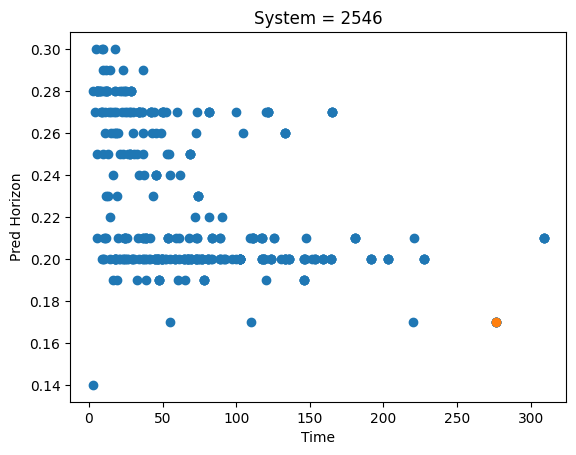

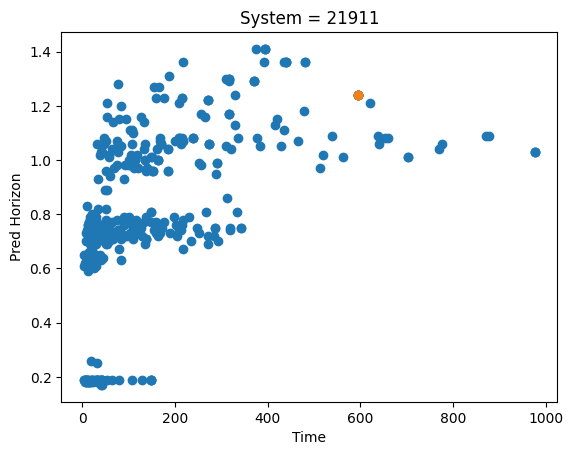

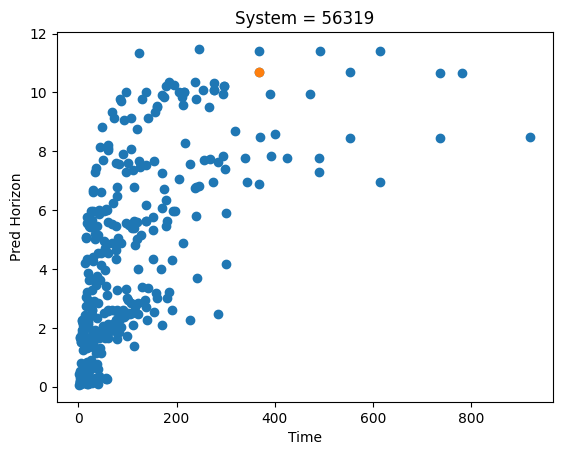

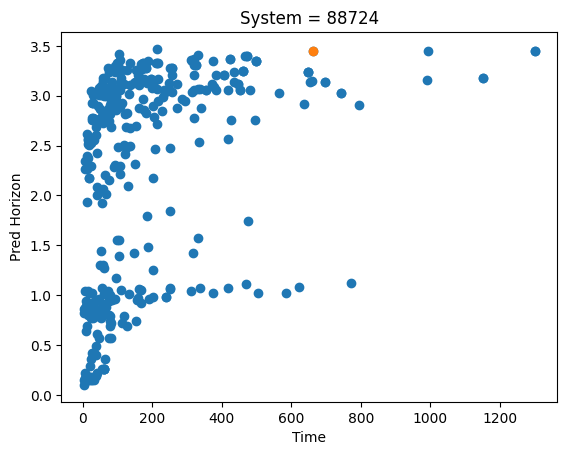

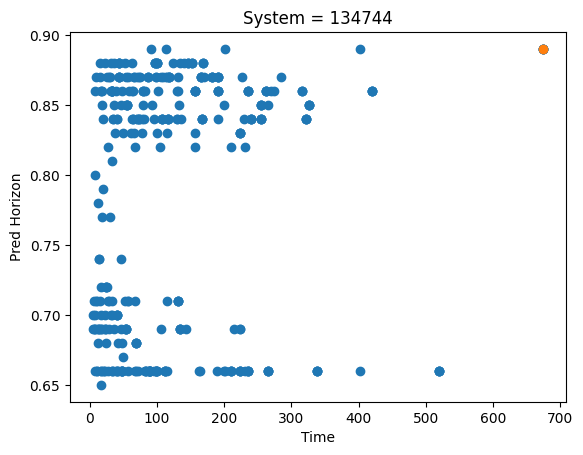

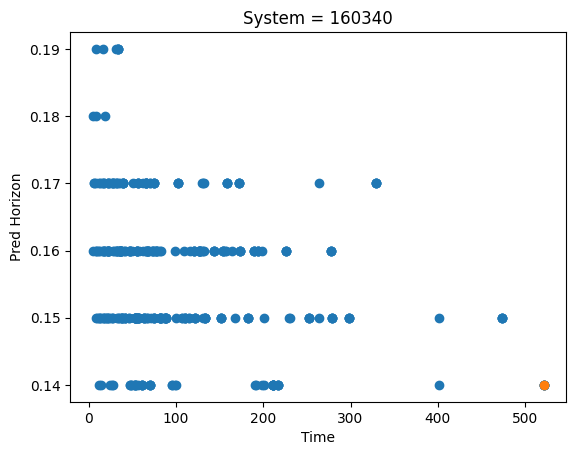

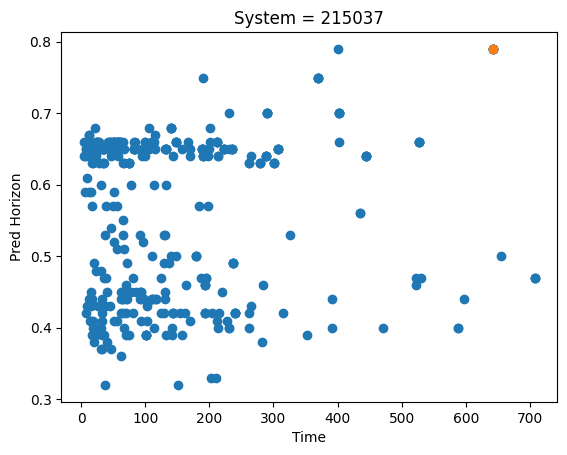

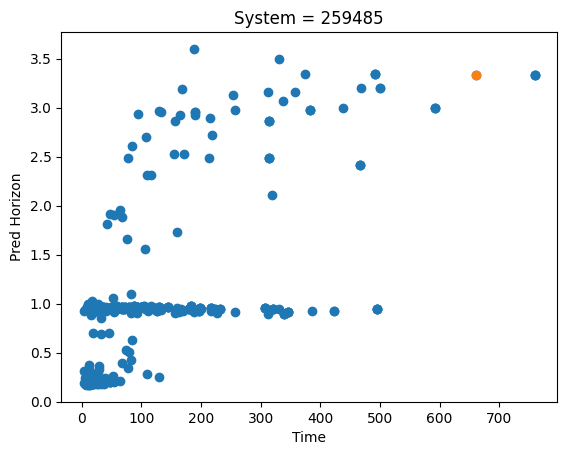

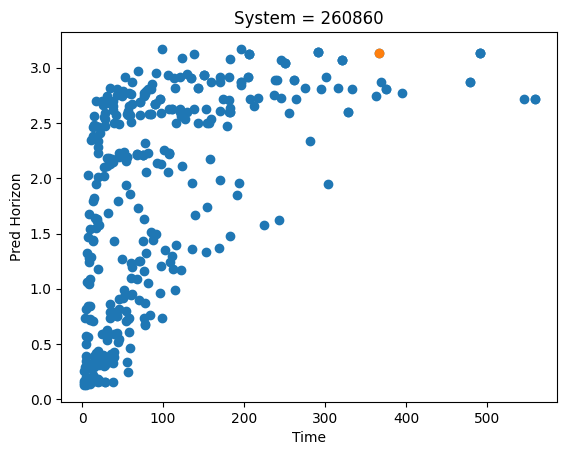

In [177]:
for s in res_df.system_id.unique():
    res_s = res_df[res_df.system_id == s]
    
    res_s = res_s.groupby(['model_id', 'epoch']).median().reset_index()

    # print(res_s.columns)
    
    subset = res_s[res_s['model_id'] == 48]
    subset = subset[subset['epoch'] == 200]
    
    plt.figure()
    plt.title("System = {}".format(s))
    plt.scatter(res_s.model_time, res_s['pred_h_mean t=0.05'])
    plt.scatter(subset["model_time"], subset['pred_h_mean t=0.05'])
    plt.xlabel("Time")
    plt.ylabel("Pred Horizon")
    plt.show()
    plt.close()